# Figure: Performance across deltas and snapshots

Produces plots for the main paper and appendix:

**Main paper** (3 TKGU ops, G-R only):
- `plot_deltas_overlay_metrics_partial.pdf` — G-BERTScore-R across temporal KG deltas
- `plot_snapshots_overlay_metrics_partial.pdf` — G-BERTScore-R across yearly KG snapshots

**Appendix** (all 5 TKGU ops, both C and G-R):
- `plot_deltas_overlay_both_metrics.pdf` — C (dashed) + G-R (solid) across deltas
- `plot_snapshots_overlay_both_metrics.pdf` — C (dashed) + G-R (solid) across snapshots

In [1]:
import os
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), 'src'))
sys.path.insert(0, os.path.join(os.path.abspath('../../..'), 'src'))

from stats.evaluation.load_results import (
    load_results,
    metrics_to_report_cie,
    models_to_load,
    model_name_to_latex,
    make_agg_and_agg_open,
    make_agg_all,
    arch_group_for_model_latex,
)

In [2]:
# =====================================================================
# OPTION A: Old pipeline cached pkls (legacy scoring — reproduces paper exactly)
# =====================================================================
# To use: set USE_OLD_PIPELINE = True
OLD_PIPELINE_CACHE_DIR = '/path/to/data/wikipedia-processing/src/stats/cache_stats/'
OLD_PIPELINE_CONFIG_PATH = '../../experiments/s14_experiments_stats_v13_ipynb/20260122_all_stats_for_tiny_slurm/config.json'
# USE_OLD_PIPELINE = True

# =====================================================================
# OPTION B: New pipeline pkl
# =====================================================================
# To use: set USE_OLD_PIPELINE = False and uncomment one PKL_PATH below.
USE_OLD_PIPELINE = False

# --- Legacy scoring + KG snapshots (13 models, reproduces paper values):
PKL_PATH = '/path/to/storage/emerge/output/experiments/s0x_evaluate_predictions/20260324_all_models_with_zs_legacy_with_kg/wiki_eval_result.pkl'
# --- Fixed scoring + KG snapshots (13 models, score_empty_predictions_as_zero=true):
# PKL_PATH = '/path/to/storage/emerge/output/experiments/s0x_evaluate_predictions/20260324_all_models_with_zs_fixed_with_kg/wiki_eval_result.pkl'
# --- Legacy scoring + KG snapshots (11 models only, no ZS):
# PKL_PATH = '/path/to/storage/emerge/output/experiments/s0x_evaluate_predictions/20260324_submitted_icml_legacy_with_kg/wiki_eval_result.pkl'

SAVE_DIR = '/path/to/storage/emerge/output/figures/'

# Assessor config — naming differs between pipelines
assessor_by_prompt_type_old = {
    'triple_assertion': 'Meta-Llama-3.1-405B_prompt_v1_triple_assertion',
    'triple_deprecation': 'Meta-Llama-3.1-405B_prompt_v1_triple_deprecation'
}
assessor_by_prompt_type_new = {
    'triple_assertion': 'Meta-Llama-3.1-405B_prompt_v1',
    'triple_deprecation': 'Meta-Llama-3.1-405B_prompt_v1'
}

In [3]:
import hashlib
import json as json_mod

if USE_OLD_PIPELINE:
    # Compute cache key (same logic as s14_load_results_v13.py)
    cache_key = hashlib.sha256(OLD_PIPELINE_CONFIG_PATH.encode("utf-8")).hexdigest()[:16]
    canonical = json_mod.dumps(assessor_by_prompt_type_old, sort_keys=True, separators=(",", ":"))
    assessor_tag = "assessor_" + hashlib.sha256(canonical.encode("utf-8")).hexdigest()[:12]
    prefix = cache_key + "_" + assessor_tag

    df_wiki_metrics_cie = pd.read_pickle(os.path.join(OLD_PIPELINE_CACHE_DIR, prefix + "_df_wiki_metrics_cie.pkl"))
    df_metrics_open_ie = pd.read_pickle(os.path.join(OLD_PIPELINE_CACHE_DIR, prefix + "_df_metrics_open_ie.pkl"))

    # Filter to models_to_load
    df_wiki_metrics_cie = df_wiki_metrics_cie[df_wiki_metrics_cie['model'].isin(set(models_to_load))]
    df_metrics_open_ie = df_metrics_open_ie[df_metrics_open_ie['model'].isin(set(models_to_load))]

    print(f'Loaded from old pipeline cache: {OLD_PIPELINE_CACHE_DIR}')
    print(f'Cache prefix: {prefix}')
else:
    (df_wiki_metrics_cie, df_metrics_open_ie, df_preds_gt_cie,
     df_preds_open_ie, df_instances, df_additional_stats) = load_results(
        pkl_path=PKL_PATH,
        assessor_by_prompt_type=assessor_by_prompt_type_new,
        filter_models=models_to_load,
    )

print(f'df_wiki_metrics_cie.shape: {df_wiki_metrics_cie.shape}')
print(f'Models: {sorted(df_wiki_metrics_cie.model.unique().tolist())}')
print(f'delta_weeks present: {"delta_weeks" in df_wiki_metrics_cie.columns}')
print(f'snapshot_year present: {"snapshot_year" in df_wiki_metrics_cie.columns}')

spec = pd.DataFrame(metrics_to_report_cie)

df_wiki_metrics_cie.shape: (4065003, 10)
df_wiki_metrics_cie_filtered.shape: (3934254, 10)
df_preds_gt_cie.shape: (56686, 24)
df_preds_gt_cie_filtered.shape: (43563, 25)


df_wiki_metrics_cie.shape: (4161300, 12)


Models: ['edc-plus-azure_ai/Mistral-Large-2411', 'edc-plus-azure_ai/Mistral-small', 'edc-plus-open-ai/gpt-5.1/non-canonicalized', 'kg-gen/azure/gpt5.1', 'kg-gen/azure_ai/Mistral-Large-2411', 'kg-gen/azure_ai/Mistral-small', 'rakg/azure_ai/Mistral-Large-2411', 'rakg/azure_ai/Mistral-small', 'rebel', 'relik-cie', 'relik-oie']
delta_weeks present: True
snapshot_year present: True


## Plotting function

In [4]:
def plot_by_tkgu_overlay_metrics(
    agg_all_by_snapshot,
    model_name_to_latex,
    allowed_models=None,
    exclude_groups=("LLM-as-a-judge",),
    aggfunc="mean",
    metrics=("completeness", "gj-recall"),
    metric_alias=None,
    metric_linestyles=None,
    x_col="delta_weeks",
    x_label=None,
    y_col="score_scaled",
    title_map=None,
    model_groups_to_plot=None,
    tkgu_types_to_plot=None,
    height=2.6,
    aspect=0.9,
    palette="colorblind",
    marker="o",
    linewidth=1.8,
    sharex=True,
    legend_position="top",
    top_legend_first_row_n=3,
    save_path=None,
    save_format="pdf",
    dpi=300,
    group_models_by_arch=True,
    show_model_legend=False,
    show_panel_titles=True,
):
    """
    Overlay-metrics plot:
    - columns = tkgu types
    - hue = model_group (colors)
    - linestyle = metric (solid/dashed)
    """
    if isinstance(metrics, str):
        metrics = (metrics,)
    metrics = list(metrics)

    if metric_alias is None:
        metric_alias = {}
    if title_map is None:
        title_map = {}
    if metric_linestyles is None:
        default_cycle = ["solid", "dashed", "dotted", "dashdot"]
        metric_linestyles = {m: default_cycle[i % len(default_cycle)] for i, m in enumerate(metrics)}

    if allowed_models is None:
        allowed_models = set(model_name_to_latex.keys())
    else:
        allowed_models = set(allowed_models)

    df = agg_all_by_snapshot.copy()
    df = df[df["model"].isin(allowed_models)]
    if exclude_groups and "group" in df.columns:
        df = df[~df["group"].isin(exclude_groups)]
    df = df[df["metric"].isin(metrics)].copy()

    if tkgu_types_to_plot is not None:
        df = df[df["tkgu_type"].isin(set(tkgu_types_to_plot))].copy()

    df[x_col] = pd.to_numeric(df[x_col], errors="coerce")
    df = df.dropna(subset=[x_col, y_col, "tkgu_type", "model", "metric"])

    df["model_latex"] = df["model"].map(lambda m: model_name_to_latex.get(m, m))
    if group_models_by_arch:
        df["model_group"] = df["model_latex"].map(arch_group_for_model_latex)
    else:
        df["model_group"] = df["model_latex"]

    if model_groups_to_plot is not None:
        df = df[df["model_group"].isin(set(model_groups_to_plot))].copy()

    if df.empty:
        raise ValueError("No rows to plot after filtering.")

    series = (
        df.groupby(["metric", "tkgu_type", "model_group", x_col], as_index=False)[y_col]
          .agg(aggfunc)
          .sort_values(["tkgu_type", "model_group", "metric", x_col])
    )

    if tkgu_types_to_plot is not None:
        tkgu_order = list(tkgu_types_to_plot)
    else:
        tkgu_order = list(series["tkgu_type"].dropna().unique())

    series["tkgu_title"] = series["tkgu_type"].map(lambda t: title_map.get(t, t))
    col_order = [title_map.get(t, t) for t in tkgu_order]
    series["metric_disp"] = series["metric"].map(lambda m: metric_alias.get(m, m))

    sns.set_style("whitegrid")
    hue_order = list(series["model_group"].dropna().unique())
    pal = sns.color_palette(palette, n_colors=max(1, len(hue_order)))

    g = sns.relplot(
        data=series, x=x_col, y=y_col,
        hue="model_group", hue_order=hue_order,
        col="tkgu_title", col_order=col_order,
        kind="line", marker=marker, palette=pal,
        facet_kws={"sharey": False, "sharex": sharex},
        height=height, aspect=aspect, linewidth=linewidth,
        style="metric_disp",
        style_order=[metric_alias.get(m, m) for m in metrics],
        dashes=False, legend=False,
    )

    for ax in g.axes.flatten():
        if show_panel_titles:
            title = ax.get_title()
            if " = " in title:
                title = title.split(" = ", 1)[1]
            ax.set_title(title, fontsize=12)
        else:
            ax.set_title("")
        ax.tick_params(axis="both", which="major", labelsize=11)

    x_ticks = sorted(series[x_col].dropna().unique().tolist())
    for ax in g.axes.flatten():
        ax.set_xticks(x_ticks)

    if x_col == "snapshot_year":
        short_labels = [f"'{int(x) % 100:02d}" for x in x_ticks]
        for ax in g.axes.flatten():
            ax.set_xticklabels(short_labels)

    if x_label is None:
        x_label = x_col
    g.figure.text(0.50, -0.03, str(x_label), ha="center", va="center", fontsize=12)

    # Apply metric-specific linestyles
    metric_disp_order = [metric_alias.get(m, m) for m in metrics]
    metric_style_order = [metric_linestyles[m] for m in metrics]
    n_metrics = len(metric_disp_order)
    for ax in g.axes.flatten():
        for i, ln in enumerate(ax.lines):
            mi = i % n_metrics
            ln.set_linestyle(metric_style_order[mi])

    # Global y-limits
    ymin = float(series[y_col].min())
    ymax = float(series[y_col].max())
    pad = 0.03 * (ymax - ymin) if ymax > ymin else 0.03
    for ax in g.axes.flatten():
        ax.set_ylim(ymin - pad, ymax + pad)
        ax.yaxis.set_major_locator(plt.MultipleLocator(10))
        ax.grid(True, axis="y", which="major")

    # y-label only on first axis
    if len(g.axes.flatten()) > 0:
        metric_labels = [metric_alias.get(m, m) for m in metrics]
        g.axes.flatten()[0].set_ylabel(" / ".join(metric_labels), fontsize=12)
    for ax in g.axes.flatten()[1:]:
        ax.set_ylabel("")
        ax.tick_params(axis="y", which="both", left=False, labelleft=False)
        ax.spines["left"].set_visible(False)

    # Model legend
    if show_model_legend and legend_position != "none":
        model_handles = [
            Line2D([0], [0], color=pal[i], lw=linewidth, marker=marker,
                   linestyle="solid", label=hue_order[i])
            for i in range(len(hue_order))
        ]
        leg = g.figure.legend(
            model_handles, [h.get_label() for h in model_handles],
            loc="upper center", bbox_to_anchor=(0.5, 1.10),
            ncol=len(model_handles), fontsize=11,
            frameon=False, columnspacing=1.2, handletextpad=0.6,
        )
        g.figure.add_artist(leg)
        plt.subplots_adjust(top=0.82)

    plt.subplots_adjust(bottom=0.12, wspace=0.10)
    for ax in g.axes.flatten():
        ax.set_xlabel("")

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        g.figure.savefig(save_path, format=save_format, dpi=dpi, bbox_inches="tight")

    return g

## Plot 1: Deltas (top panel)

No overlapping (metric, evaluator_model, model) between agg and agg_open.
sanity check, all have to be in 1: 5    180
Name: count, dtype: int64


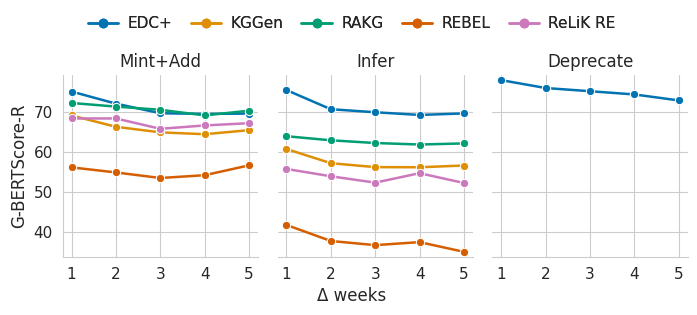

In [5]:
# Aggregate by delta_weeks
agg_by_delta, agg_open_by_delta = make_agg_and_agg_open(
    df_wiki_metrics_cie=df_wiki_metrics_cie,
    df_metrics_open_ie=df_metrics_open_ie,
    spec=spec,
    groupby_cols=['tkgu_type', 'model', 'metric', 'evaluator_model', 'delta_weeks']
)
agg_all_by_delta = make_agg_all(agg_by_delta, agg_open_by_delta)

# Filter to relevant metrics
mask = (
    ((agg_all_by_delta["metric"] == "completeness") &
     (agg_all_by_delta["evaluator_model"] == "all-mpnet-base-v2"))
    |
    ((agg_all_by_delta["metric"] == "gj-recall") &
     (agg_all_by_delta["evaluator_model"] == "bert-base"))
)
agg_all_by_delta_filtered = agg_all_by_delta.loc[mask].copy()

op_map = {
    'x-triples': 'Exists',
    'e-triples': 'Add',
    'ee-triples': 'Mint+Add',
    'ee-kg-triples': 'Infer',
    'd-triples': 'Deprecate',
}

os.makedirs(SAVE_DIR, exist_ok=True)

g = plot_by_tkgu_overlay_metrics(
    agg_all_by_snapshot=agg_all_by_delta_filtered,
    model_name_to_latex=model_name_to_latex,
    allowed_models=models_to_load,
    metrics=("gj-recall",),
    metric_alias={"completeness": "Completeness", "gj-recall": "G-BERTScore-R"},
    metric_linestyles={"completeness": "dashed", "gj-recall": "solid"},
    x_col="delta_weeks",
    x_label="\u0394 weeks",
    y_col="score_scaled",
    title_map=op_map,
    tkgu_types_to_plot=['ee-triples', 'ee-kg-triples', 'd-triples'],
    model_groups_to_plot=["EDC+", "KGGen", "RAKG", "ReLiK RE", "REBEL", "ReLiK cIE"],
    legend_position="top",
    save_path=os.path.join(SAVE_DIR, "plot_deltas_overlay_metrics_partial.pdf"),
    show_model_legend=True,
)
plt.show()

## Plot 2: Snapshots (bottom panel)

No overlapping (metric, evaluator_model, model) between agg and agg_open.
sanity check, all have to be in 1: 7    180
Name: count, dtype: int64


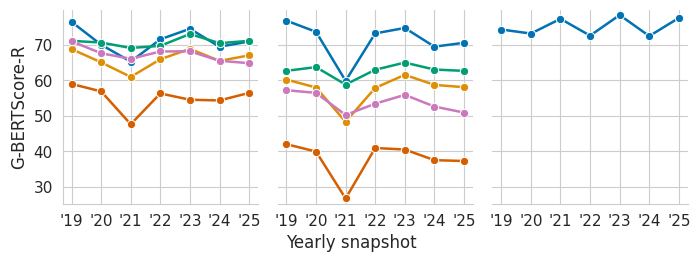

In [6]:
# Aggregate by snapshot_year
agg_by_snap, agg_open_by_snap = make_agg_and_agg_open(
    df_wiki_metrics_cie=df_wiki_metrics_cie,
    df_metrics_open_ie=df_metrics_open_ie,
    spec=spec,
    groupby_cols=['tkgu_type', 'model', 'metric', 'evaluator_model', 'snapshot_year']
)
agg_all_by_snap = make_agg_all(agg_by_snap, agg_open_by_snap)

mask = (
    ((agg_all_by_snap["metric"] == "completeness") &
     (agg_all_by_snap["evaluator_model"] == "all-mpnet-base-v2"))
    |
    ((agg_all_by_snap["metric"] == "gj-recall") &
     (agg_all_by_snap["evaluator_model"] == "bert-base"))
)
agg_all_by_snap_filtered = agg_all_by_snap.loc[mask].copy()

g = plot_by_tkgu_overlay_metrics(
    agg_all_by_snapshot=agg_all_by_snap_filtered,
    model_name_to_latex=model_name_to_latex,
    allowed_models=models_to_load,
    metrics=("gj-recall",),
    metric_alias={"completeness": "Completeness", "gj-recall": "G-BERTScore-R"},
    metric_linestyles={"completeness": "dashed", "gj-recall": "solid"},
    x_col="snapshot_year",
    x_label="Yearly snapshot",
    y_col="score_scaled",
    title_map=op_map,
    tkgu_types_to_plot=['ee-triples', 'ee-kg-triples', 'd-triples'],
    model_groups_to_plot=["EDC+", "KGGen", "RAKG", "ReLiK RE", "REBEL", "ReLiK cIE"],
    legend_position="top",
    save_path=os.path.join(SAVE_DIR, "plot_snapshots_overlay_metrics_partial.pdf"),
    show_model_legend=False,
    show_panel_titles=False,
)
plt.show()

## Appendix: Deltas — all TKGU ops, both C and G-R

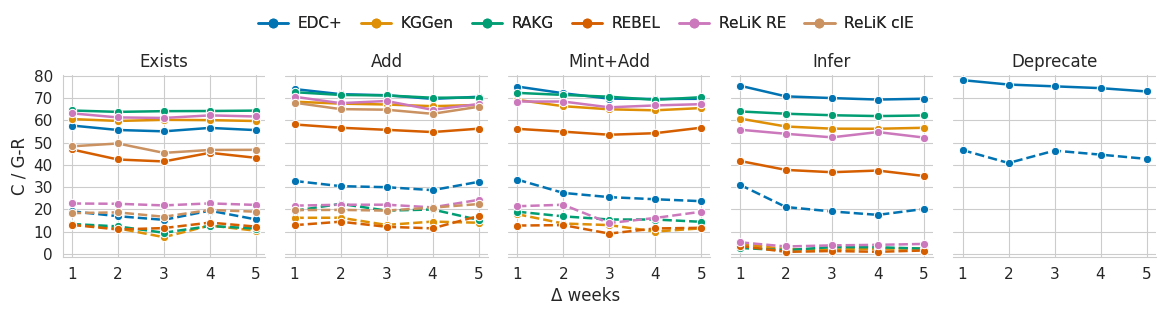

In [7]:
g = plot_by_tkgu_overlay_metrics(
    agg_all_by_snapshot=agg_all_by_delta_filtered,
    model_name_to_latex=model_name_to_latex,
    allowed_models=models_to_load,
    metrics=("completeness", "gj-recall"),
    metric_alias={"completeness": "C", "gj-recall": "G-R"},
    metric_linestyles={"completeness": "dashed", "gj-recall": "solid"},
    x_col="delta_weeks",
    x_label="\u0394 weeks",
    y_col="score_scaled",
    title_map=op_map,
    tkgu_types_to_plot=['x-triples', 'e-triples', 'ee-triples', 'ee-kg-triples', 'd-triples'],
    model_groups_to_plot=["EDC+", "KGGen", "RAKG", "ReLiK RE", "REBEL", "ReLiK cIE"],
    legend_position="top",
    save_path=os.path.join(SAVE_DIR, "plot_deltas_overlay_both_metrics.pdf"),
    show_model_legend=True,
)
plt.show()

## Appendix: Snapshots — all TKGU ops, both C and G-R

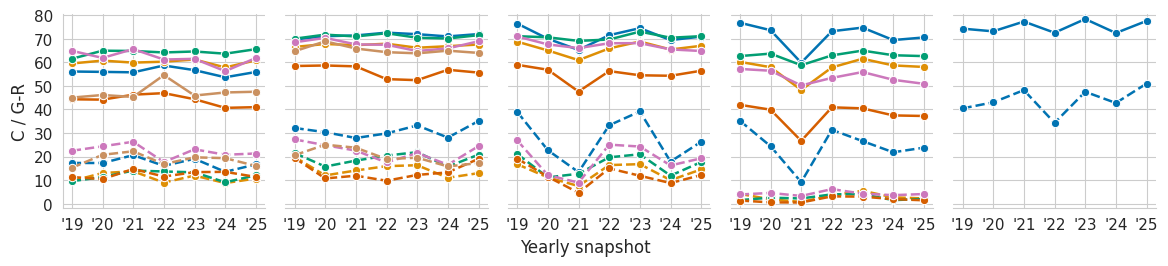

In [8]:
g = plot_by_tkgu_overlay_metrics(
    agg_all_by_snapshot=agg_all_by_snap_filtered,
    model_name_to_latex=model_name_to_latex,
    allowed_models=models_to_load,
    metrics=("completeness", "gj-recall"),
    metric_alias={"completeness": "C", "gj-recall": "G-R"},
    metric_linestyles={"completeness": "dashed", "gj-recall": "solid"},
    x_col="snapshot_year",
    x_label="Yearly snapshot",
    y_col="score_scaled",
    title_map=op_map,
    tkgu_types_to_plot=['x-triples', 'e-triples', 'ee-triples', 'ee-kg-triples', 'd-triples'],
    model_groups_to_plot=["EDC+", "KGGen", "RAKG", "ReLiK RE", "REBEL", "ReLiK cIE"],
    legend_position="top",
    save_path=os.path.join(SAVE_DIR, "plot_snapshots_overlay_both_metrics.pdf"),
    show_model_legend=False,
    show_panel_titles=False,
)
plt.show()